# ColonySearch — Hyperparameter Tuning Benchmark

Compares **PSO**, **QPSO**, **Grid Search**, and **Random Search** on local node search quality.
All nodes in `data/dbs/` are used together so the optimiser sees every topic cluster.

Metric: **NDCG@3** — ground truth = documents sharing the same topic label on the same node.

In [ ]:
import sys
from pathlib import Path

# Walk up from CWD until we find the project root (works wherever Jupyter is launched)
_ROOT = Path().resolve()
for _ in range(6):
    if (_ROOT / 'data' / 'dbs').exists():
        break
    _ROOT = _ROOT.parent
sys.path.insert(0, str(_ROOT))

import importlib
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from data.tuning.ground_truth import load_all_ground_truth
from data.tuning.metrics import evaluate
import data.tuning.local_search as local_search
from data.tuning.algos import BOUNDS
from data.tuning.algos.pso import PSO
from data.tuning.algos.qpso import QPSO
from data.tuning.algos.grid_search import GridSearch
from data.tuning.algos.random_search import RandomSearch

importlib.reload(local_search)
clear_index_cache = local_search.clear_index_cache
resolve_svd_dims = local_search.resolve_svd_dims

DATA_DIR = _ROOT / 'data'
K = 3
print(f'Project root: {_ROOT}')

ImportError: cannot import name 'clear_index_cache' from 'data.tuning.local_search' (/home/lukas/Documents/Uni/THN/IntroBC/ColonySearch/data/tuning/local_search.py)

## Parameter Bounds

These are the search ranges for all three algorithms.  
Edit this cell to explore different parts of the space.

In [ ]:
# BOUNDS is imported from algos/__init__.py — one source of truth.
# Format: [(min, max), ...] for [link_bias, svd_dims, alpha]
print('Parameter bounds:')
labels = ['link_bias  (link-graph weight vs text embeddings)', 'svd_dims   (link-graph SVD dimensions, rounded to int)', 'alpha      (BM25 weight in final score; 1-alpha = KNN weight)']
for (lo, hi), label in zip(BOUNDS, labels):
    print(f'  {label}')
    print(f'      range: [{lo}, {hi}]')

# You can override bounds for a specific algo by passing them explicitly:
#   QPSO(bounds=[(0.0, 1.0), (8, 64), (0.0, 1.0)])  <- narrower search
print()
print('Current BOUNDS:', BOUNDS)

Parameter bounds:
  link_bias  (link-graph weight vs text embeddings)
      range: [0.0, 2.0]
  svd_dims   (link-graph SVD dimensions, rounded to int)
      range: [8, 128]
  alpha      (BM25 weight in final score; 1-alpha = KNN weight)
      range: [0.0, 1.0]

Current BOUNDS: [(0.0, 2.0), (8, 128), (0.0, 1.0)]


In [ ]:
import importlib
import data.tuning.ground_truth as gt
import random

importlib.reload(gt)
print('Loading ground truth across all nodes ...')

USE_SHARED_QUERIES = True
QUERY_MODE = "llm"  # "llm" | "topic" | "mixed"
LLM_QUERY_COUNT = 50
LLM_QUERY_CACHE = DATA_DIR / "tuning" / "llm_queries.json"
LLM_QUERY_SEED = None  # set int for reproducible sampling
LLM_ALLOW_FILL = False  # set True to call the LLM for missing cache entries
TOPIC_QUERIES_PER_TOPIC = 2
TOPIC_QUERY_STYLE = "mixed"
QUERY_SAMPLE_SIZE = 70  # limit eval time on large query sets
if USE_SHARED_QUERIES:
    if QUERY_MODE == "llm":
        queries = gt.generate_llm_doc_queries(
            DATA_DIR,
            n_queries=LLM_QUERY_COUNT,
            cache_path=LLM_QUERY_CACHE,
            seed=LLM_QUERY_SEED,
            allow_llm_fill=LLM_ALLOW_FILL,
        )
    elif QUERY_MODE == "topic":
        topics = gt.extract_topics(DATA_DIR)
        queries = gt.generate_topic_queries(topics, n_per_topic=TOPIC_QUERIES_PER_TOPIC, style=TOPIC_QUERY_STYLE)
    elif QUERY_MODE == "mixed":
        topics = gt.extract_topics(DATA_DIR)
        topic_queries = gt.generate_topic_queries(topics, n_per_topic=TOPIC_QUERIES_PER_TOPIC, style=TOPIC_QUERY_STYLE)
        llm_queries = gt.generate_llm_doc_queries(
            DATA_DIR,
            n_queries=LLM_QUERY_COUNT,
            cache_path=LLM_QUERY_CACHE,
            seed=LLM_QUERY_SEED,
            allow_llm_fill=LLM_ALLOW_FILL,
        )
        seen = set()
        queries = []
        for q in llm_queries + topic_queries:
            key = (q.get("query_text", ""), q.get("topic", ""))
            if key in seen:
                continue
            seen.add(key)
            queries.append(q)
    else:
        raise ValueError("QUERY_MODE must be: 'llm', 'topic', or 'mixed'")
    test_cases = gt.load_shared_ground_truth(DATA_DIR, queries)
else:
    test_cases = load_all_ground_truth(DATA_DIR)

total_cases = len(test_cases)
if QUERY_SAMPLE_SIZE is not None and total_cases > QUERY_SAMPLE_SIZE:
    test_cases = random.sample(test_cases, k=QUERY_SAMPLE_SIZE)
    print(f"\nSampling {QUERY_SAMPLE_SIZE} random queries from {total_cases} total")

unique_clusters = len({frozenset(tc['relevant_urls']) for tc in test_cases})
print(f"\nTotal: {len(test_cases)} test queries across {unique_clusters} topic clusters")

# Show test queries; set NODE_FILTER to [] for all nodes
NODE_FILTER = []  # e.g. ['Node_1', 'Node_3']
cases_to_show = [tc for tc in test_cases if not NODE_FILTER or tc['node_dir'].name in NODE_FILTER]
print('\nTest queries (preview):')
for tc in cases_to_show[:50]:
    print(f"- [{tc['node_dir'].name}] {tc['query_text'][:120]}...")

if USE_SHARED_QUERIES:
    print('\nShared queries (preview):')
    seen = set()
    for tc in test_cases:
        qt = tc['query_text']
        if qt in seen:
            continue
        seen.add(qt)
        print(f"- {qt}")
        if len(seen) >= 50:
            break

Loading ground truth across all nodes ...
Using 50 cached LLM queries
  Node_1: 50 shared test cases
  Node_10: 50 shared test cases
  Node_2: 50 shared test cases
  Node_3: 50 shared test cases
  Node_4: 50 shared test cases
  Node_5: 50 shared test cases
  Node_6: 50 shared test cases
  Node_7: 50 shared test cases
  Node_8: 50 shared test cases
  Node_9: 50 shared test cases

Sampling 70 random queries from 500 total

Total: 70 test queries across 10 topic clusters

Test queries (preview):
- [Node_2] Carbon Brief policy sections and topics...
- [Node_10] route of administration medical definition...
- [Node_10] serotonin function production location...
- [Node_1] Baltic Finnic paganism religion history...
- [Node_9] Carbon Brief policy sections and topics...
- [Node_10] Luftwaffe strategy 1933-1945 Hitler Russia war...
- [Node_6] International Geophysical Year 1957 scientific collaboration Cold War...
- [Node_2] Radiomics enhanced deep multi-task learning head and neck cancer...
- [

In [ ]:
# Quick sanity sweep: verify the objective varies across random params.
clear_index_cache()
rng = np.random.default_rng(0)
n_points = 6
max_cases = 20
sample_cases = test_cases[: min(max_cases, len(test_cases))]
points = []
for _ in range(n_points):
    lb = rng.uniform(*BOUNDS[0])
    svd_raw = rng.uniform(*BOUNDS[1])
    alpha = rng.uniform(*BOUNDS[2])
    svd_eff = resolve_svd_dims(svd_raw)
    m = evaluate([lb, svd_raw, alpha], sample_cases, k=K)["mean_ndcg"]
    points.append({"lb": lb, "svd_raw": svd_raw, "svd_eff": svd_eff, "alpha": alpha, "ndcg": m})
df_sweep = pd.DataFrame(points).sort_values("ndcg", ascending=False)
display(df_sweep)
print("ndcg std:", float(df_sweep["ndcg"].std()))

## Algorithm Configuration

For a **quick test** run, use the commented-out small-budget versions below.

In [ ]:
def make_objective(test_cases, k):
    def objective(params):
        return -evaluate(params, test_cases, k=k)['mean_ndcg']
    return objective

objective_fn = make_objective(test_cases, K)

# ── Full budget (comment out for quick test) ──────────────────────────────
algos = [
    ('PSO',    PSO(n_particles=30, max_iter=20)),
    ('QPSO',   QPSO(n_particles=30, max_iter=20)),
    ('Grid',   GridSearch(n_per_dim=5)),
    ('Random', RandomSearch(n_evaluations=200)),
]

# ── Quick test (~50 evals total, a few minutes) ───────────────────────────
# algos = [
#     ('PSO',    PSO(n_particles=5, max_iter=4)),
#     ('QPSO',   QPSO(n_particles=5, max_iter=4)),
#     ('Grid',   GridSearch(n_per_dim=3)),
#     ('Random', RandomSearch(n_evaluations=27)),
# ]

import time
results = {}
for name, algo in algos:
    t0 = time.time()
    print(f'Running {name} ...')
    results[name] = algo.optimize(objective_fn)
    elapsed = time.time() - t0
    print(f'  Best NDCG@{K}: {-results[name].best_fitness:.4f}  ({results[name].n_evals} evals, {elapsed:.0f}s)')

print('\nDone.')

Running PSO ...
  Best NDCG@3: 0.9479  (600 evals, 1979s)
Running QPSO ...
  Best NDCG@3: 0.9479  (600 evals, 2079s)
Running Grid ...
  Best NDCG@3: 0.9479  (125 evals, 403s)
Running Random ...
  Best NDCG@3: 0.9479  (200 evals, 630s)

Done.


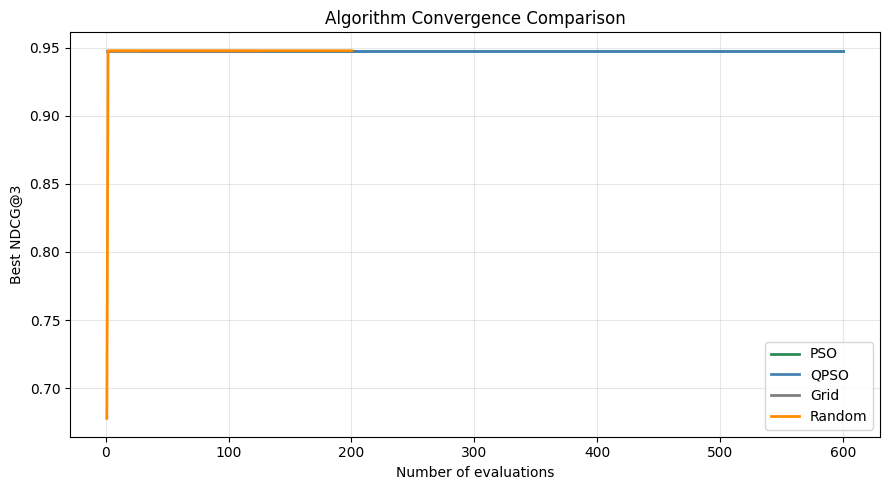

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))

colors = {'PSO': 'seagreen', 'QPSO': 'steelblue', 'Grid': 'gray', 'Random': 'darkorange'}
for name, res in results.items():
    xs = [h['n_evals']   for h in res.history]
    ys = [h['best_ndcg'] for h in res.history]
    ax.plot(xs, ys, label=name, color=colors[name], linewidth=2)

ax.set_xlabel('Number of evaluations')
ax.set_ylabel(f'Best NDCG@{K}')
ax.set_title('Algorithm Convergence Comparison')
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig('benchmark_convergence.png', dpi=120)
plt.show()

In [ ]:
rows = []
ndcg_col = f"Best NDCG@{K}"
prec_col = f"Best Precision@{K}"
rec_col = f"Best Recall@{K}"
for name, res in results.items():
    lb, svd, alpha = res.best_params
    metrics = evaluate(res.best_params, test_cases, k=K)
    rows.append({
        'Algorithm':         name,
        ndcg_col:            round(metrics['mean_ndcg'], 4),
        prec_col:            round(metrics['mean_precision'], 4),
        rec_col:             round(metrics['mean_recall'], 4),
        'Total Evals':       res.n_evals,
        'Best Params':       f'lb={lb:.2f}, svd={resolve_svd_dims(svd)}, a={alpha:.2f}',
    })

df = pd.DataFrame(rows).set_index('Algorithm')
display(df.style.highlight_max(subset=[ndcg_col, prec_col, rec_col]))

,Best NDCG@3,Best Precision@3,Best Recall@3,Total Evals,Best Params
Algorithm,,,,,
PSO,0.947900,0.518500,0.820100,600,"lb=0.45, svd=75, a=0.06"
QPSO,0.947900,0.518500,0.820100,600,"lb=0.45, svd=75, a=0.06"
Grid,0.947900,0.518500,0.820100,125,"lb=0.00, svd=8, a=0.00"
Random,0.947900,0.518500,0.820100,200,"lb=0.70, svd=33, a=0.09"


## Grid Search Heatmap

NDCG@3 across `alpha × link_bias` with `svd_dims` fixed at the best value found.

Sweeping alpha x link_bias (svd_dims=8) ...


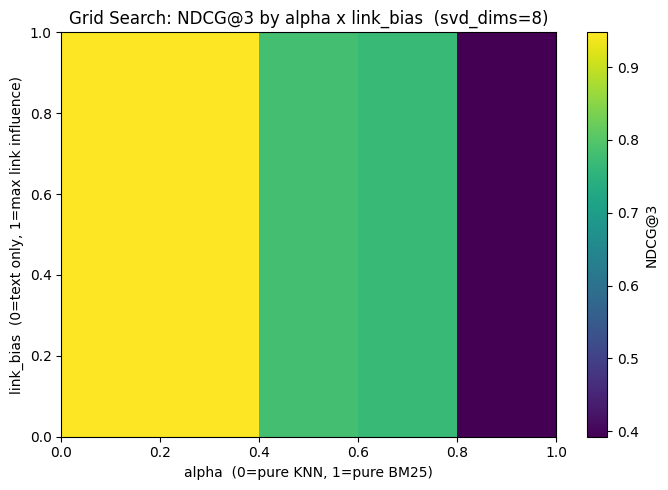

In [ ]:
grid_res = results['Grid']
best_lb, best_svd, best_alpha = grid_res.best_params
best_svd_int = resolve_svd_dims(best_svd)

n = 5
lb_vals    = np.linspace(0.0, 1.0, n)
alpha_vals = np.linspace(0.0, 1.0, n)

print(f'Sweeping alpha x link_bias (svd_dims={best_svd_int}) ...')
ndcg_grid = np.zeros((n, n))
for i, lb in enumerate(lb_vals):
    for j, al in enumerate(alpha_vals):
        m = evaluate([lb, best_svd_int, al], test_cases, k=K)
        ndcg_grid[i, j] = m['mean_ndcg']

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(ndcg_grid, origin='lower', aspect='auto',
               extent=[0, 1, 0, 1], cmap='viridis')
fig.colorbar(im, ax=ax, label=f'NDCG@{K}')
ax.set_xlabel('alpha  (0=pure KNN, 1=pure BM25)')
ax.set_ylabel('link_bias  (0=text only, 1=max link influence)')
ax.set_title(f'Grid Search: NDCG@{K} by alpha x link_bias  (svd_dims={best_svd_int})')
fig.tight_layout()
plt.show()

In [ ]:
# ── Save grid search results for figure_generation.ipynb ─────────────────
# ndcg_grid, lb_vals, alpha_vals, best_svd_int are already in scope from the
# heatmap cell above — just persist them so figure_generation.ipynb can load
# without re-running the expensive search.

import json as _json
from pathlib import Path as _Path
from collections import Counter as _Counter

# Determine which svd_dims dominated the top-10 individual grid points.
# best_svd_int (from cell-10) is the best params' svd — use it as the fixed dim.
_svd_fixed = best_svd_int

_log_path = _Path("grid_search_results.json")
_log_path.write_text(_json.dumps({
    "ndcg_grid":      ndcg_grid.tolist(),
    "lb_vals":        lb_vals.tolist(),
    "alpha_vals":     alpha_vals.tolist(),
    "svd_dims_fixed": _svd_fixed,
    "k":              K,
}, indent=2))
print(f"Grid log saved → {_log_path.resolve()}")
print(f"  svd_dims fixed : {_svd_fixed}")
print(f"  grid shape     : {ndcg_grid.shape}  (link_bias × alpha)")


Grid log saved → /home/lukas/Documents/Uni/THN/IntroBC/ColonySearch/data/tuning/grid_search_results.json
  svd_dims fixed : 8
  grid shape     : (5, 5)  (link_bias × alpha)


## QPSO Particle Trace

Each point is one evaluated position in the `link_bias × alpha` plane (svd_dims collapsed).
Colour = NDCG@3 at that point; red star = global best.

Running QPSO trace (separate run for visualisation) ...


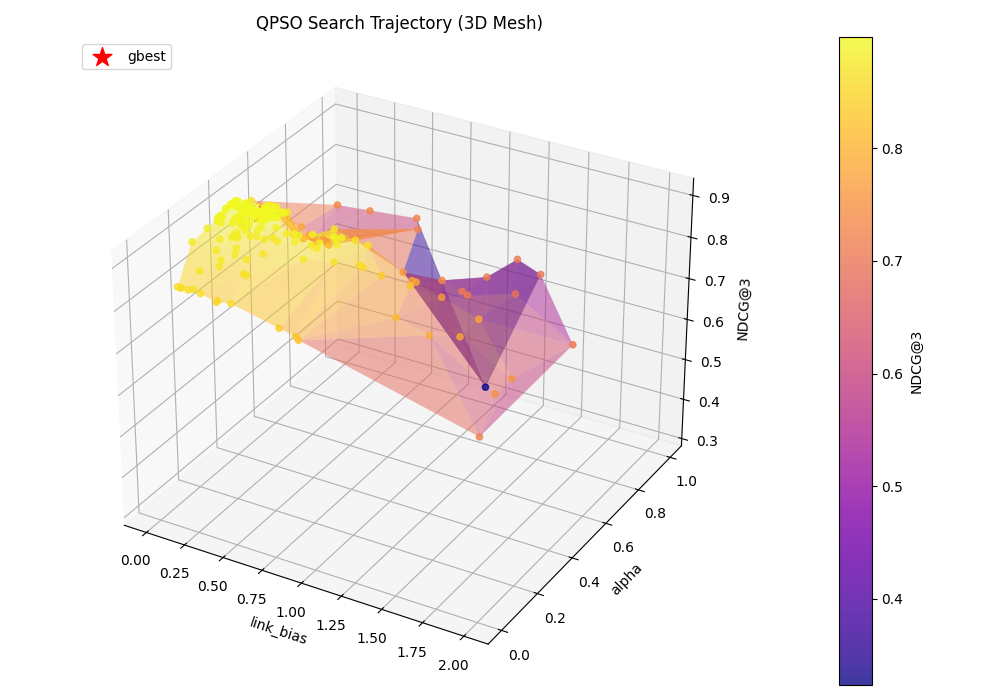

QPSO trace best: NDCG=0.8985  params=[0.192, 23.67, 0.393]


In [ ]:
%matplotlib widget

import json
from pathlib import Path

TRACE_DIR = DATA_DIR / "tuning"
TRACE_DIR.mkdir(parents=True, exist_ok=True)
TRACE_PATH = TRACE_DIR / "qpso_trace.json"
REUSE_TRACE = True
positions = []
trace_payload = None

if REUSE_TRACE and TRACE_PATH.exists():
    trace_payload = json.loads(TRACE_PATH.read_text())
    positions = trace_payload.get("positions", [])
    best_lb = trace_payload.get("best_lb")
    best_alpha = trace_payload.get("best_alpha")
    best_ndcg = trace_payload.get("best_ndcg")
    best_params = trace_payload.get("best_params")
    print(f"Loaded QPSO trace → {TRACE_PATH}")
else:
    def recording_objective(params):
        m = evaluate(params, test_cases, k=K)
        positions.append((float(params[0]), float(params[2]), m['mean_ndcg']))
        return -m['mean_ndcg']

    print('Running QPSO trace (separate run for visualisation) ...')
    qpso_trace = QPSO(n_particles=20, max_iter=10, seed=99)
    trace_res = qpso_trace.optimize(recording_objective)
    best_lb, _, best_alpha = trace_res.best_params
    best_ndcg = -trace_res.best_fitness
    best_params = [round(x, 6) for x in trace_res.best_params]
    trace_payload = {
        "algo": "QPSO",
        "k": K,
        "positions": positions,
        "best_lb": best_lb,
        "best_alpha": best_alpha,
        "best_ndcg": best_ndcg,
        "best_params": best_params,
        "n_positions": len(positions),
    }
    TRACE_PATH.write_text(json.dumps(trace_payload, indent=2))
    print(f"Saved QPSO trace → {TRACE_PATH}")

if not positions:
    raise ValueError("No QPSO trace positions available.")

lbs, alphas, ndcgs = zip(*positions)

import matplotlib.tri as mtri
tri = mtri.Triangulation(lbs, alphas)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot_trisurf(tri, ndcgs, cmap='plasma', alpha=0.5, linewidth=0.2)
sc = ax.scatter(lbs, alphas, ndcgs, c=ndcgs, cmap='plasma', s=20, alpha=0.8)
fig.colorbar(sc, ax=ax, pad=0.12, label=f'NDCG@{K}')
ax.scatter([best_lb], [best_alpha], [best_ndcg], marker='*', s=200, color='red', zorder=5, label='gbest')
ax.set_xlabel('link_bias')
ax.set_ylabel('alpha')
ax.set_zlabel(f'NDCG@{K}')
ax.set_title('QPSO Search Trajectory (3D Mesh)')
ax.legend(loc='upper left')
fig.tight_layout()
plt.show()
print(f'QPSO trace best: NDCG={best_ndcg:.4f}  params={best_params}')

Running PSO trace (separate run for visualisation) ...


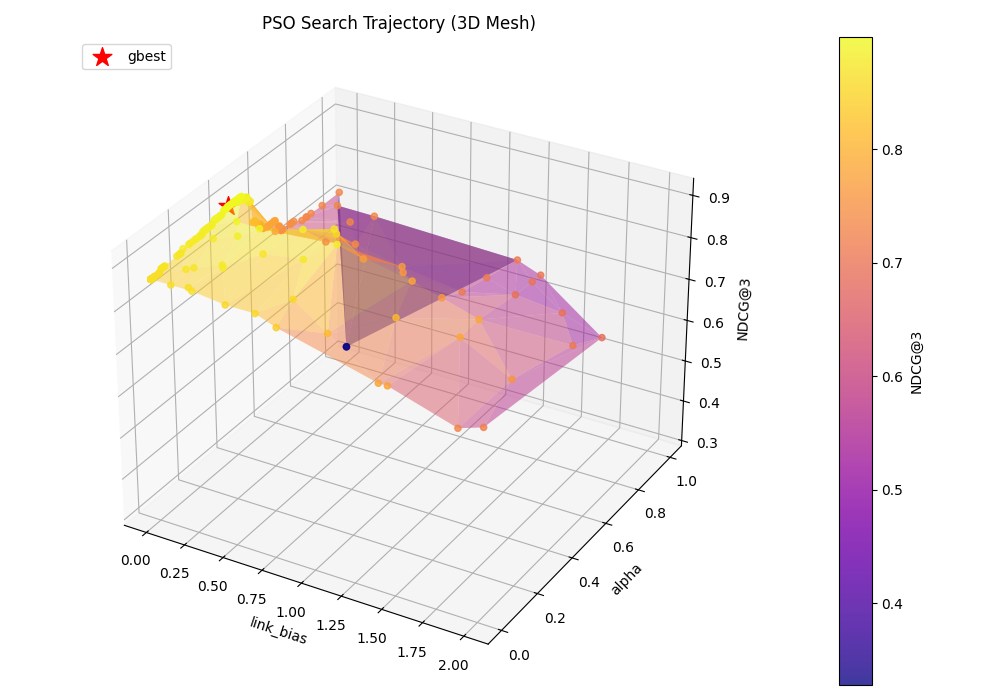

PSO trace best: NDCG=0.8985  params=[0.0, 34.914, 0.383]


In [ ]:
%matplotlib widget

import json
from pathlib import Path

TRACE_DIR = DATA_DIR / "tuning"
TRACE_DIR.mkdir(parents=True, exist_ok=True)
TRACE_PATH = TRACE_DIR / "pso_trace.json"
REUSE_TRACE = True
pso_positions = []
trace_payload = None

if REUSE_TRACE and TRACE_PATH.exists():
    trace_payload = json.loads(TRACE_PATH.read_text())
    pso_positions = trace_payload.get("positions", [])
    best_lb = trace_payload.get("best_lb")
    best_alpha = trace_payload.get("best_alpha")
    best_ndcg = trace_payload.get("best_ndcg")
    best_params = trace_payload.get("best_params")
    print(f"Loaded PSO trace → {TRACE_PATH}")
else:
    def pso_recording_objective(params):
        m = evaluate(params, test_cases, k=K)
        pso_positions.append((float(params[0]), float(params[2]), m['mean_ndcg']))
        return -m['mean_ndcg']

    print('Running PSO trace (separate run for visualisation) ...')
    pso_trace = PSO(n_particles=20, max_iter=10, seed=99)
    pso_trace_res = pso_trace.optimize(pso_recording_objective)
    best_lb, _, best_alpha = pso_trace_res.best_params
    best_ndcg = -pso_trace_res.best_fitness
    best_params = [round(x, 6) for x in pso_trace_res.best_params]
    trace_payload = {
        "algo": "PSO",
        "k": K,
        "positions": pso_positions,
        "best_lb": best_lb,
        "best_alpha": best_alpha,
        "best_ndcg": best_ndcg,
        "best_params": best_params,
        "n_positions": len(pso_positions),
    }
    TRACE_PATH.write_text(json.dumps(trace_payload, indent=2))
    print(f"Saved PSO trace → {TRACE_PATH}")

if not pso_positions:
    raise ValueError("No PSO trace positions available.")

lbs, alphas, ndcgs = zip(*pso_positions)

import matplotlib.tri as mtri
tri = mtri.Triangulation(lbs, alphas)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot_trisurf(tri, ndcgs, cmap='plasma', alpha=0.5, linewidth=0.2)
sc = ax.scatter(lbs, alphas, ndcgs, c=ndcgs, cmap='plasma', s=20, alpha=0.8)
fig.colorbar(sc, ax=ax, pad=0.12, label=f'NDCG@{K}')
ax.scatter([best_lb], [best_alpha], [best_ndcg], marker='*', s=200, color='red', zorder=5, label='gbest')
ax.set_xlabel('link_bias')
ax.set_ylabel('alpha')
ax.set_zlabel(f'NDCG@{K}')
ax.set_title('PSO Search Trajectory (3D Mesh)')
ax.legend(loc='upper left')
fig.tight_layout()
plt.show()
print(f'PSO trace best: NDCG={best_ndcg:.4f}  params={best_params}')